### Generative Adversarial Network (GAN)
A Generative Adversarial Network (GAN) is a type of deep learning model that consists of two neural networks, a generator and a discriminator, that are trained together in a competitive manner. The generator creates synthetic data samples, while the discriminator evaluates them against real data samples to determine their authenticity. The goal of the generator is to produce data that is indistinguishable from real data, while the discriminator aims to correctly classify real and fake data. This adversarial process helps both networks improve over time, leading to the generation of high-quality synthetic data. GANs have been widely used in various applications such as image generation, video synthesis, and text generation.

In this notebook, we will implement a simple GAN using TensorFlow and Keras to generate synthetic images. We will start by defining the architecture of the generator and discriminator networks, and then we will train the GAN on a dataset of images. Finally, we will visualize the generated images to see how well our GAN has learned to create realistic samples.

In [10]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

The MINST dataset is a collection of 70,000 handwritten digit images, each of size 28x28 pixels. It is commonly used for training and testing machine learning models in the field of computer vision. The dataset is divided into a training set of 60,000 images and a test set of 10,000 images. Each image is labeled with the corresponding digit (0-9) that it represents. The MINS dataset is widely used for tasks such as image classification, generative modeling, and anomaly detection.

In [11]:
# Load the MNIST dataset
BATCH_SIZE = 256
NOISE_DIM = 100

(train_images, _), (_, _) = tf.keras.datasets.mnist.load_data()
train_images = train_images.astype('float32')
train_images = (train_images - 127.5) / 127.5  # Normalize to [-1, 1]
train_images = train_images.reshape(-1, 784)
train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(train_images.shape[0]).batch(BATCH_SIZE)

print('Train Image Shape:',train_images.shape)

Train Image Shape: (60000, 784)


- Generator: The generator is a neural network that takes random noise as input and generates synthetic data samples. It learns to create data that resembles the real data by trying to fool the discriminator.

In [ ]:
class Generator(tf.keras.Model):
    def __init__(self):
        super(Generator, self).__init__()
        self.dense1 = layers.Dense(256, activation='relu')
        self.dense2 = layers.Dense(512, activation='relu')
        self.dense3 = layers.Dense(1024, activation='relu')
        self.dense4 = layers.Dense(784, activation='tanh')

    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        x = self.dense3(x)
        return self.dense4(x)

- Discriminator: The discriminator is a neural network that takes both real and synthetic data samples as input and tries to classify them correctly. It learns to distinguish between real and fake data, providing feedback to the generator to improve its output.

In [13]:
class Discriminator(tf.keras.Model):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.dense1 = layers.Dense(1024, activation='relu')
        self.dense2 = layers.Dense(512, activation='relu')
        self.dense3 = layers.Dense(256, activation='relu')
        self.dense4 = layers.Dense(1, activation='sigmoid')

    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        x = self.dense3(x)
        return self.dense4(x)

- Optimized and Loss Functions: The GAN is trained using two separate loss functions for the generator and discriminator. The generator's loss function encourages it to produce data that can fool the discriminator, while the discriminator's loss function encourages it to correctly classify real and fake data. The optimization process involves updating the weights of both networks based on their respective loss functions, allowing them to improve iteratively over time.

In [14]:
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

cross_entropy = tf.keras.losses.BinaryCrossentropy()
generator_optimizer = tf.keras.optimizers.Adam(5e-5)
discriminator_optimizer = tf.keras.optimizers.Adam(5e-5)

generator = Generator()
generator.build(input_shape=(None, NOISE_DIM))
discriminator = Discriminator()
discriminator.build(input_shape=(None, 784))

/Users/macbook/.pyenv/versions/3.11.9/lib/python3.11/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'generator', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/Users/macbook/.pyenv/versions/3.11.9/lib/python3.11/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'discriminator', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


- Training Loop: The training process of a GAN involves alternating between training the discriminator and the generator. In each iteration, the discriminator is trained on a batch of real data samples and a batch of synthetic data samples generated by the generator. After updating the discriminator's weights, the generator is trained using the feedback from the discriminator to improve its ability to generate realistic data. This iterative process continues until the generator produces high-quality synthetic data that can effectively fool the discriminator.

In [15]:
def train_batch(real_images):
    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)
        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(generated_images, training=True)
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

In [16]:
def plot_generated_images(generator, epoch):
    noise = tf.random.normal([16, NOISE_DIM])
    generated_images = generator(noise, training=False)
    generated_images = generated_images.numpy().reshape(-1, 28, 28)

    fig, axes = plt.subplots(4, 4, figsize=(4, 4))
    for i in range(16):
        ax = axes[i // 4, i % 4]
        ax.imshow(generated_images[i], cmap='gray')
        ax.axis('off')
    plt.suptitle(f'Epoch {epoch}')
    plt.show()

In [17]:
def train_model(epochs):
    for epoch in range(epochs):
        for real_images in train_dataset:
            train_batch(real_images)
        if (epoch + 1) % 10 == 0:
            plot_generated_images(generator, epoch + 1)

2026-03-15 08:29:53.170090: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-15 08:30:29.292892: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-15 08:46:24.153561: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-15 08:48:49.956302: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


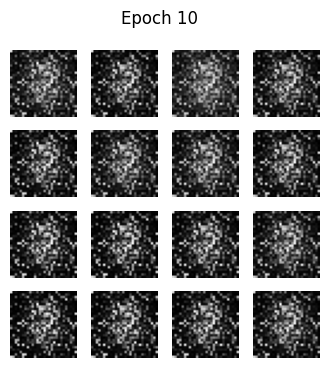

2026-03-15 08:53:51.174128: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


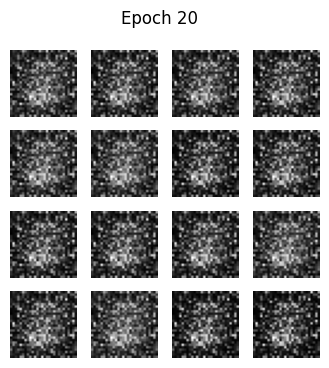

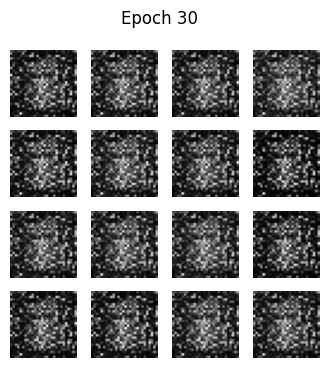

2026-03-15 08:59:30.416501: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


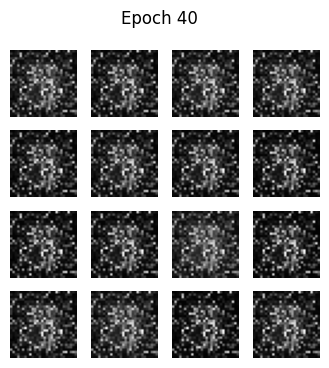

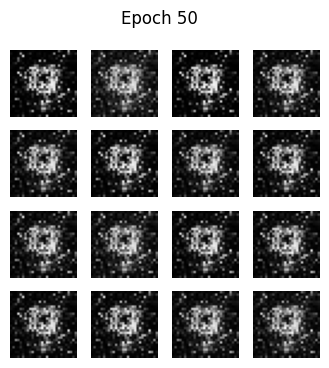

In [18]:
#training the GAN and displaying images
seed = tf.random.normal([64, NOISE_DIM])
train_model(50)